In [3]:
#!python -m pip install numpy pandas matplotlib seaborn

In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách hiển thị biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Thêm thư mục cha (root) vào hệ thống để có thể gọi các hàm từ thư mục 'src/'
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_raw_data, load_movie_titles

In [ ]:
# Định nghĩa đường dẫn (đứng từ thư mục notebooks/ đi ra ngoài rồi vào data/raw/)
data_path = os.path.join('..', 'data', 'raw', 'u.data')
item_path = os.path.join('..', 'data', 'raw', 'u.item')

df = load_raw_data(data_path)
movie_titles = load_movie_titles(item_path)

print("--- THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU MOVIELENS 100K ---")
print(f"Tổng số bản ghi đánh giá (Ratings): {df.shape[0]}")
print(f"Số lượng người dùng duy nhất (Users): {df['user_id'].nunique()}")
print(f"Số lượng bộ phim duy nhất (Movies): {df['item_id'].nunique()}")
print("\n5 dòng dữ liệu đầu tiên:")
display(df.head())

--- THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU MOVIELENS 100K ---
Tổng số bản ghi đánh giá (Ratings): 100000
Số lượng người dùng duy nhất (Users): 943
Số lượng bộ phim duy nhất (Movies): 1682

5 dòng dữ liệu đầu tiên:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


C:\Users\Will\AppData\Local\Temp\ipykernel_11324\3239699947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='rating', data=df, palette='viridis')


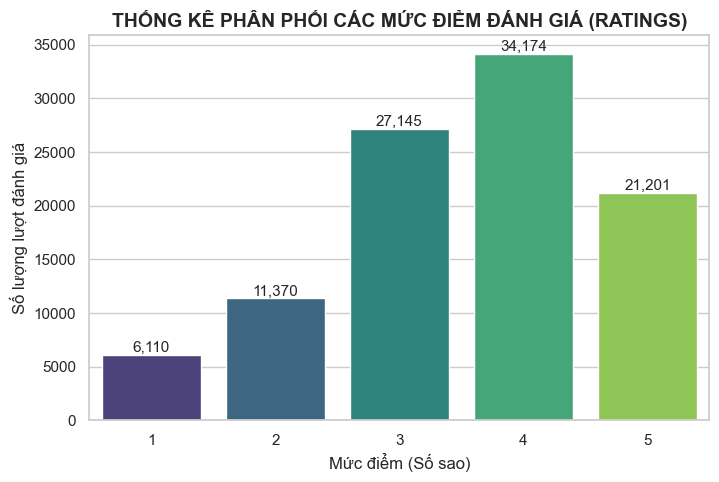

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='rating', data=df, palette='viridis')

# Thêm số lượng cụ thể lên đầu mỗi cột biểu đồ
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

plt.title('THỐNG KÊ PHÂN PHỐI CÁC MỨC ĐIỂM ĐÁNH GIÁ (RATINGS)', fontsize=14, fontweight='bold')
plt.xlabel('Mức điểm (Số sao)', fontsize=12)
plt.ylabel('Số lượng lượt đánh giá', fontsize=12)

# Xuất file ảnh chất lượng cao để chèn vào báo cáo Word
plt.savefig('rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Will\AppData\Local\Temp\ipykernel_11324\1931332175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='watch_count', y='movie_title', data=top_movies, palette='magma')


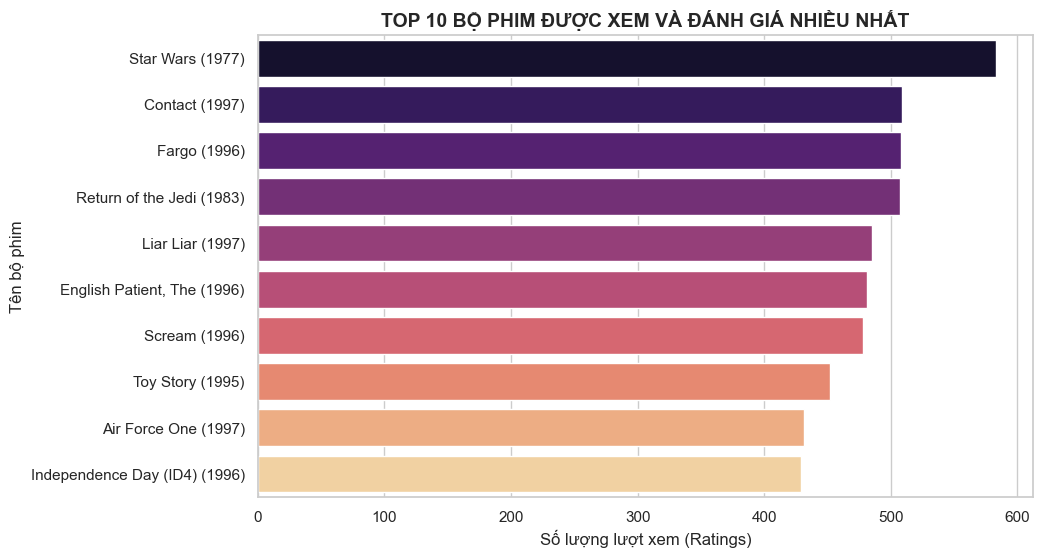

In [7]:
# Đếm số lượt xuất hiện của từng bộ phim
top_movies = df['item_id'].value_counts().head(10).reset_index()
top_movies.columns = ['item_id', 'watch_count']

# Ánh xạ từ ID sang Tên phim cụ thể
top_movies['movie_title'] = top_movies['item_id'].map(movie_titles)

# Vẽ biểu đồ thanh ngang
sns.barplot(x='watch_count', y='movie_title', data=top_movies, palette='magma')
plt.title('TOP 10 BỘ PHIM ĐƯỢC XEM VÀ ĐÁNH GIÁ NHIỀU NHẤT', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng lượt xem (Ratings)', fontsize=12)
plt.ylabel('Tên bộ phim', fontsize=12)

plt.savefig('top_10_popular_movies.png', dpi=300, bbox_inches='tight')
plt.show()

--- THỐNG KÊ HÀNH VI NGƯỜI DÙNG ---
Số lượng phim trung bình một người xem: 106.0 bộ phim
Người dùng xem ít phim nhất: 20 bộ phim
Người dùng xem nhiều phim nhất: 737 bộ phim


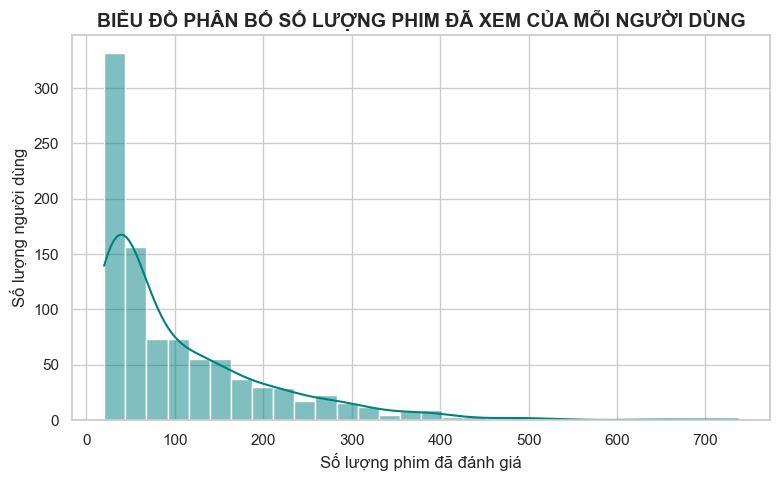

In [8]:
user_counts = df['user_id'].value_counts()

print("--- THỐNG KÊ HÀNH VI NGƯỜI DÙNG ---")
print(f"Số lượng phim trung bình một người xem: {user_counts.mean():.1f} bộ phim")
print(f"Người dùng xem ít phim nhất: {user_counts.min()} bộ phim")
print(f"Người dùng xem nhiều phim nhất: {user_counts.max()} bộ phim")

# Vẽ biểu đồ mật độ phân bố
plt.figure(figsize=(9, 5))
sns.histplot(user_counts, bins=30, kde=True, color='teal')
plt.title('BIỂU ĐỒ PHÂN BỐ SỐ LƯỢNG PHIM ĐÃ XEM CỦA MỖI NGƯỜI DÙNG', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng phim đã đánh giá', fontsize=12)
plt.ylabel('Số lượng người dùng', fontsize=12)

plt.savefig('user_engagement_distribution.png', dpi=300, bbox_inches='tight')
plt.show()